In [1]:
import os
from pathlib import Path
from datetime import datetime

import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
import geopandas as gpd
import matplotlib.pyplot as plt
import xarray as xr 

import hydromt
from hydromt._utils import log
from hydromt_sfincs import SfincsModel
from sfincs_utils import run_sfincs
from hydromt import DataCatalog

log.initialize_logging()
log.set_log_level(log_level=20)

proj = ccrs.PlateCarree() # plot projection

# 1a: Configure model - data catalog -----------------------------------------------------
catalog = hydromt.DataCatalog(data_libs = ['data_catalog_v1.yml', 'artifact_data']) # 'artifact_data', 'deltares_data'])
# can possibly take things out of my own data_catalog if i use the predefined ones 

# 1b - Configure model - model domain ----------------------------------------------------
deltas = catalog.get_geodataframe('40_delta_polygons')

# Filter specific delta 
target_basin_id = 620947 # small in australia 
# target_basin_id = 908572

region = deltas[deltas['BasinID2'] == target_basin_id]

# Load the hydrobasins that intersect with the selected delta
gdf_basin = catalog.get_geodataframe(
    'hydrobasins_global',
    geom=region # only load basins that intersect with our region of interest
)

sf = SfincsModel(
    data_libs= ["data_catalog_v1.yml"],  # specify which data libraries to use
    root="tmp_sfincs_compound",  # specify the root directory for the model
    mode="w+",  # specify the mode for opening the model (r=read only, r+=append, w=write, w+=overwrite
    write_gis=True,  # specify whether to write GIS data
)


2026-01-06 11:16:00,911 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from data_catalog_v1.yml
2026-01-06 11:16:01,425 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Reading data catalog artifact_data latest
2026-01-06 11:16:01,426 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from C:\Users\lasch\.hydromt\artifact_data\v1.0.0\data_catalog.yml
2026-01-06 11:16:02,323 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading 40_delta_polygons GeoDataFrame data from C:\PhD\SFINCS\SFINCS_cloned\input\delta_polygons\40_delta_polygons.geojson
2026-01-06 11:16:02,335 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading hydrobasins_global GeoDataFrame data from C:\PhD\SFINCS\SFINCS_cloned\input\hydrobasins_global.gpkg
2026-01-06 11:16:02,382 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from data_catalog_v1.yml
2026-01-06 11:16:02,460 - hydr

In [2]:
catalog

,provider,version,uri,data_type,driver,crs,category,notes,paper_doi,paper_ref,...,source_version,unit,url,license,nodata,author,history,info,processing_notes,timestamp
name,,,,,,,,,,,,,,,,,,,,,
40_delta_polygons,None,None,C:/PhD/SFINCS/SFINCS_cloned/input/delta_polygo...,GeoDataFrame,PyogrioDriver,4326,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
outflow_niger,None,None,C:/PhD/SFINCS/SFINCS_cloned/input/outflow_nige...,GeoDataFrame,PyogrioDriver,4326,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hydrobasins_global,None,None,C:/PhD/SFINCS/SFINCS_cloned/input/hydrobasins_...,GeoDataFrame,PyogrioDriver,4326,hydrography,Global HydroBASINS level 12 polygons,10.5194/hess-17-2029-2013,Lehner et al. (2013),...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
merit,None,None,P:/wflow_global/hydromt/topography/merit/merit.nc,RasterDataset,RasterDatasetXarrayDriver,4326,NaN,NaN,10.1002/2017GL072874,Yamazaki et al. (2018),...,1.0.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gebco,None,2020,gebco.tif,RasterDataset,RasterioDriver,4326,topography,NaN,10.5285/a29c5465-b138-234d-e053-6c86abc040b9,Weatherall et al (2020),...,NaN,m+MSL,https://www.bodc.ac.uk/data/open_download/gebc...,https://www.gebco.net/data_and_products/gridde...,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
simard,None,None,simard.tif,RasterDataset,RasterioDriver,4326,landuse & landcover,NaN,10.1029/2011JG001708,Simard et al (2011),...,NaN,NaN,https://webmap.ornl.gov/ogc/dataset.jsp?ds_id=...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
soilgrids,None,2017,soilgrids/{variable}.tif,RasterDataset,RasterioDriver,4326,soil,soilthickness is based on 1) soilgrids (global...,10.1371/journal.pone.0169748,Hengl et al. (2017),...,NaN,NaN,https://www.isric.org/explore/soilgrids/faq-so...,ODbL,NaN,NaN,NaN,NaN,NaN,NaN
vito_2015,None,2.0.2,vito.tif,RasterDataset,RasterioDriver,4326,landuse & landcover,NaN,10.5281/zenodo.3939038,Buchhorn et al (2020),...,NaN,NaN,https://land.copernicus.eu/global/products/lc,NaN,NaN,NaN,NaN,NaN,NaN,NaN


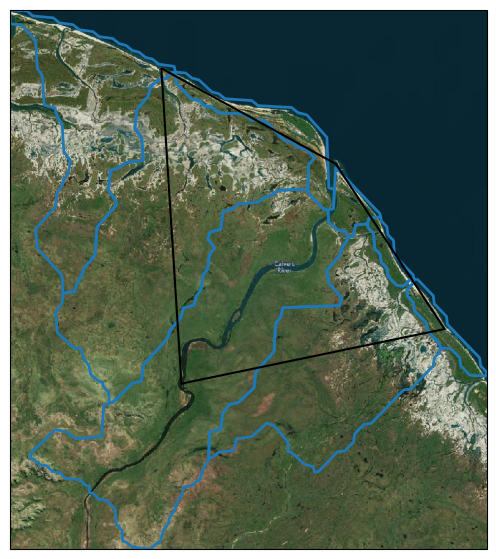

In [3]:
# Plot the initially chosen region (black box), and all the basins (partially) within the region (blue outlines).
# The model domain will be all those river basins plus the coast line.

fig = plt.figure(figsize=(10,7))
ax= plt.subplot(projection=proj)
ax.add_image(cimgt.QuadtreeTiles(),12)

# Plot the hydrobasins
gdf_basin['geometry'].boundary.plot(ax=ax, label='basins', lw=2)

# Plot the region of interest
region.boundary.plot(ax=ax,color='k', label='region')

# Set the extent of the plot to the extent of the region of interest
ax.set_extent(gdf_basin['geometry'].total_bounds[[0,2,1,3]], crs=proj)

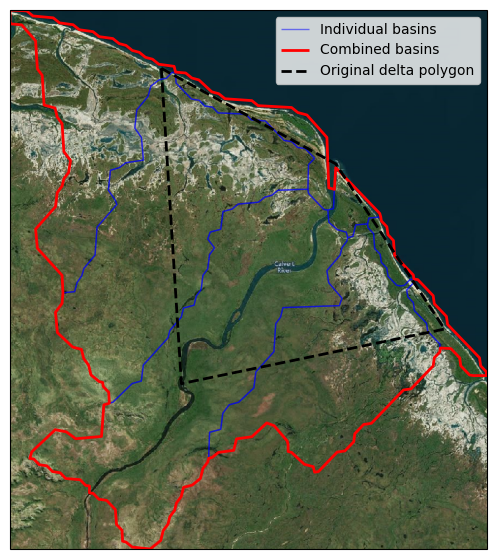

In [28]:
# Create a combined polygon from all the basins that overlap with the delta
total_polygon = gdf_basin.dissolve()  # Keep as GeoDataFrame, not just .geometry

# Visualize the combined polygon
fig = plt.figure(figsize=(10,7))
ax = plt.subplot(projection=proj)
ax.add_image(cimgt.QuadtreeTiles(), 12)

# Plot the individual basin boundaries (in blue)
gdf_basin['geometry'].boundary.plot(ax=ax, label='Individual basins', lw=1, color='blue', alpha=0.5)
total_polygon.boundary.plot(ax=ax, label='Combined basins', lw=2, color='red')
region.boundary.plot(ax=ax, color='k', label='Original delta polygon', lw=2, linestyle='--')

ax.set_extent(gdf_basin['geometry'].total_bounds[[0,2,1,3]], crs=proj)
ax.legend()
plt.show()

2026-01-06 11:50:32,255 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from data_catalog_v1.yml
2026-01-06 11:50:32,763 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Reading data catalog artifact_data latest
2026-01-06 11:50:32,764 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from C:\Users\lasch\.hydromt\artifact_data\v1.0.0\data_catalog.yml
2026-01-06 11:50:34,622 - hydromt.model.model - model - INFO - Initializing sfincs model from hydromt_sfincs (v2.0.0rc1).
2026-01-06 11:50:34,622 - hydromt.model.model - model - WARNING - No region component found in components.
2026-01-06 11:50:34,642 - hydromt.hydromt_sfincs.components.config.config - config - INFO - Updating 9 attributes in model config.


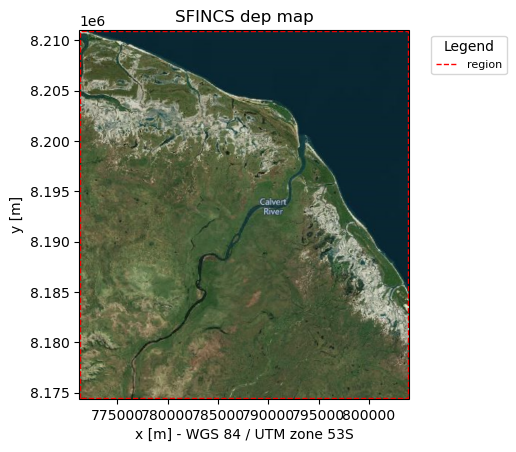

In [29]:
# 2: Initialize and define model grid --------------------------------------------------------

# Specify root_folder and logger_name
root_folder  = Path('C:/PhD/SFINCS/SFINCS_cloned/output') / f'sfincs_{target_basin_id}'
logger_name = 'SFINCS_log'
# logger = log(logger_name, log_level=10)

# initialize model
sf = SfincsModel(
    data_libs = ['data_catalog_v1.yml', 'artifact_data'],
    root=root_folder, # where to?
    mode="w+", # whether to read, append or write model
    write_gis= True, # write model grid to GIS files
)

# Create model grid 
model_res = 100

sf.grid.create_from_region(
    region = {'bbox': total_polygon.to_crs('EPSG:4326').total_bounds},  # use combined polygon for model domain
    res = model_res,
    rotated=False, # non-rotated grid. 
    crs='utm' # automatically the closest UTM zone is selected (unit is in meters), 
)

# Plot model region
fig, ax = sf.plot_basemap(plot_region=True,bmap='sat')

2026-01-06 11:50:39,741 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading merit RasterDataset data from P:\wflow_global\hydromt\topography\merit\merit.nc


2026-01-06 11:50:39,941 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading gebco RasterDataset data from P:\wflow_global\hydromt\bathymetry\gebco\gebco.vrt


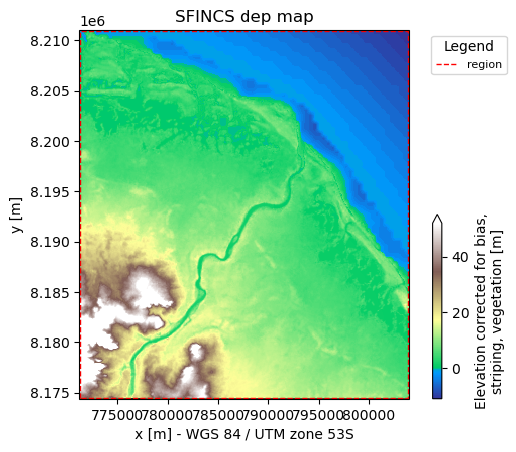

In [30]:
# 3: Build model elevation --------------------------------------------------------

elevation_list = [
    {'elevation': 'merit', 'zmin': 0.001},
    {'elevation': 'gebco'}
]

# We define the list here in Python. 
dep = sf.elevation.create(elevation_list = elevation_list)

sf.grid

# Plot the elevation on top of the model region and satellite image. The variable argument sets which model variable to plot
_ = sf.plot_basemap(variable='dep', bmap='sat', plot_region=True)

2026-01-06 11:51:18,772 - hydromt.hydromt_sfincs.components.grid.mask - mask - INFO - 0 gaps outside valid elevation range < 10.0 km2.
2026-01-06 11:51:18,830 - hydromt.hydromt_sfincs.components.config.config - config - INFO - Updating 2 attributes in model config.


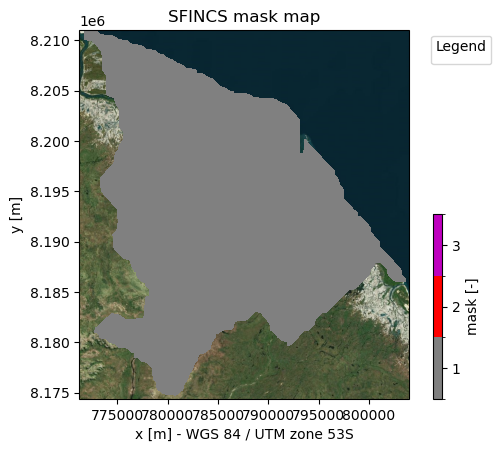

In [31]:
# 4: Define active cells --------------------------------------------------------

# Define active cells within the combined basin polygon
sf.mask.create_active(include_polygon= total_polygon)

# Make a plot of the mask file
_ = sf.plot_basemap(
    variable="mask", plot_region=False, plot_bounds=True, bmap="sat", zoomlevel=12
)

2026-01-06 11:54:08,580 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: mask


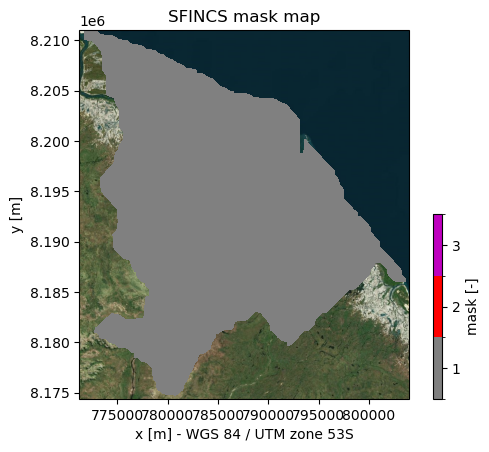

In [ ]:
# 5: Define boundary conditions --------------------------------------------------------

sf.mask.create_boundary(
    btype="waterlevel",
    zmax=-4,            # -4m = because it is below intertidal zone but not too far offshore
    reset_bounds=True,
)

# remove outflow boundaries 
# gdf_include = sf.data_catalog.get_geodataframe(
#     "outflow_niger"
# )
# sf.mask.create_boundary(
#     btype="outflow",
#     include_polygon=gdf_include,
#     reset_bounds=True,
# # )

# Make a plot of the mask file
fig, ax = sf.plot_basemap(
    variable="mask", plot_region=False, plot_bounds=False, bmap="sat", zoomlevel=12
)

# # plot the shapefile given by the user as dashed line
# gdf_include.to_crs(sf.crs).boundary.plot(ax=ax, color="k", lw=1, ls="--")

In [ ]:
# Surface roughness setup --------------------------------------------------------
roughness_list = [
    {
        'lulc': 'esa_worldcover',                 # landuse/landcover dataset
        'reclass_table': 'esa_worldcover_mapping' # reclassification table
    }
]

sf.roughness.create(roughness_list)

_ = sf.plot_basemap(variable="manning", plot_bounds=False, bmap="sat", zoomlevel=12)

2026-01-06 11:54:37,991 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading esa_worldcover RasterDataset data from P:\wflow_global\hydromt\landuse\esa_worldcover\esa-worldcover.vrt
2026-01-06 11:54:46,317 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading esa_worldcover_mapping DataFrame data from C:\PhD\SFINCS\SFINCS_cloned\input\esa_worldcover_mapping.csv


In [35]:
# TODO doesnt work

# # Infiltration data setup --------------------------------------------------------
# antecedent_moisture = 'avg' 

# sf.infiltration.create_cn(
#     'gcn250', antecedent_moisture=antecedent_moisture
# )

In [88]:
# Set up sub-grid ---------------------------------------------------------
sf.subgrid.create(
    elevation_list= elevation_list,
    roughness_list = roughness_list,
    nr_subgrid_pixels = 10,             # Fill in number of subgrid files
    write_dep_tif=True,                 # save a cloud-optimized geotiff of the subgrid topography
    write_man_tif=False,
    nrmax=5000,                         # set tile size a bit larger speed up processing (default 2000)
)

# make sure to write the updated model to the new model root before running sfincs
sf.write()

2026-01-05 11:39:26,504 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading merit RasterDataset data from P:\wflow_global\hydromt\topography\merit\merit.nc
2026-01-05 11:39:26,729 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading gebco RasterDataset data from P:\wflow_global\hydromt\bathymetry\gebco\gebco.vrt
2026-01-05 11:39:26,794 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading esa_worldcover RasterDataset data from P:\wflow_global\hydromt\landuse\esa_worldcover\esa-worldcover.vrt
2026-01-05 11:39:34,720 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading esa_worldcover_mapping DataFrame data from C:\PhD\SFINCS\SFINCS_cloned\input\esa_worldcover_mapping.csv
2026-01-05 11:39:35,976 - hydromt.hydromt_sfincs.components.grid.subgrid - subgrid - INFO - Number of regular cells in a block : 500
2026-01-05 11:39:35,978 - hydromt.hydromt_sfincs.components.grid.subgrid - subgrid - INFO - Number of blo

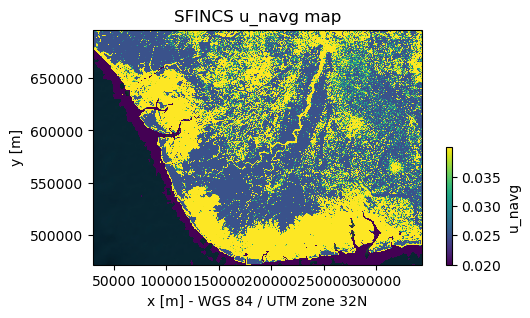

In [89]:
# See the subgrid table variales
sf.subgrid.data

# we can plot the 2D subgrid variables
_ = sf.plot_basemap(
    variable=sf.subgrid.data["u_navg"], plot_bounds=False, bmap="sat", zoomlevel=12
)

In [ ]:
# 4: Add forcing --------------------------------------------------------
# TODO 

# Specify the simulation time in the model config
sf.config.update = (
    {
        "tref": datetime(2018, 12, 1),
        "tstart": datetime(2018, 12, 1),
        "tstop": datetime(2018, 12, 3),
    # "dtout": 3600, # map-output timestep in seconds
    # "dthisout" : 600, # point-output timestep in seconds
    }
)

# print gtsm nc info
gtsm_test = sf.data_catalog.get_geodataframe(
    "gtsm_reanalysis_2018_hourly_v1")

print(gtsm_test)

# error that no data was read from source - something to do with delta being small? CHange to larger delta to test - still didnt work
sf.water_level.create(geodataset = 'gtsm_reanalysis_2018_hourly_v1',
                      buffer=10000, # even with 10 000, still no data is read from the source 
                      merge=True) # or false since theres no other orcing data yet?

# From geodataset (from artifact_data catalog)
# sf.water_level.create(geodataset = 'gtsmv3_eu_era5')

2026-01-05 12:27:06,071 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading gtsm_reanalysis_2018_hourly_v1 GeoDataset data from C:\PhD\SFINCS\SFINCS_cloned\input\reanalysis_waterlevel_hourly_2018_12_v1.nc
<xarray.DataArray 'waterlevel' (time: 744, index: 43119)> Size: 257MB
dask.array<open_dataset-waterlevel, shape=(744, 43119), dtype=float64, chunksize=(744, 10), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 6kB 2018-12-01 ... 2018-12-31T23:00:00
  * index        (index) uint16 86kB 0 1 2 3 4 ... 43729 43730 43731 43732 43733
    lon          (index) float64 345kB dask.array<chunksize=(10,), meta=np.ndarray>
    lat          (index) float64 345kB dask.array<chunksize=(10,), meta=np.ndarray>
    spatial_ref  int64 8B 0
Attributes:
    long_name:    sea_surface_height_above_mean_sea_level
    units:        m
    short_name:   waterlevel
    description:  Total water level resulting from the combination of barotro...
2026-01-05 12:27:3

NoDataException: No data was read from source

In [ ]:
# Add rainfall, windspeed and airpressure forcing --------------------------------------------------------

# # Rainfall
# sf.setup_precip_forcing_from_grid(
#     precip='era5_hourly',
#     aggregate=False
# )

# # Windspeed
# sf.setup_wind_forcing_from_grid(
#     wind = 'era5_hourly'
# )

# # Airpressure 
# sf.setup_pressure_forcing_from_grid(
#     press='era5_hourly'
# )

### Water level forcing

For the forcing of the water levels at the boundary we use the Global Tide and Surge Model (GTSM). This includes hourly waterlevels at predetermined points. To get the waterlevels at our boundary we interpolate these points to our boundary when we read in the data. The `buffer` we provide specifies the distance from our boundary to look for points in the GTSM dataset.  


In [95]:
# DO THIS AFTER FIGURING OUT GTSM 

# # visualising where the points lie in the dataset to check they are local data 
# import xarray as   xr
# wl_path = Path(sf.data_catalog.get_source('gtsm_reanalysis_2018_hourly_v1').path) 
# ds = xr.open_dataset(wl_path)
# ds

# print gtsm nc info
ds = sf.data_catalog.get_geodataframe(
    "gtsm_reanalysis_2018_hourly_v1")

print(ds)

# # Plot the locations of the waterlevel points
fig = plt.figure(figsize=(10, 7))
ax = plt.subplot(projection=proj)
ax.add_image(cimgt.QuadtreeTiles(), 8)

# Plot the points
ax.scatter(ds['lon'], ds['lat'], transform=ccrs.PlateCarree(), color='red', label='GTSM points', zorder=10)

# Add coastlines for reference
ax.coastlines()

ax.legend()
plt.show()

2026-01-05 12:30:31,992 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading gtsm_reanalysis_2018_hourly_v1 GeoDataset data from C:\PhD\SFINCS\SFINCS_cloned\input\reanalysis_waterlevel_hourly_2018_12_v1.nc
<xarray.DataArray 'waterlevel' (time: 744, index: 43119)> Size: 257MB
dask.array<open_dataset-waterlevel, shape=(744, 43119), dtype=float64, chunksize=(744, 10), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 6kB 2018-12-01 ... 2018-12-31T23:00:00
  * index        (index) uint16 86kB 0 1 2 3 4 ... 43729 43730 43731 43732 43733
    lon          (index) float64 345kB dask.array<chunksize=(10,), meta=np.ndarray>
    lat          (index) float64 345kB dask.array<chunksize=(10,), meta=np.ndarray>
    spatial_ref  int64 8B 0
Attributes:
    long_name:    sea_surface_height_above_mean_sea_level
    units:        m
    short_name:   waterlevel
    description:  Total water level resulting from the combination of barotro...
HTTP Error 504: Ga

MemoryError: Unable to allocate 11.9 GiB for an array with shape (65281, 65281, 3) and data type uint8

<Figure size 1000x700 with 1 Axes>

Storm surge height for basin 620947: 2.16743204794323 m
2025-12-23 08:46:47,089 - SFINCS_log - dataframe - DEBUG - Slicing time dime (datetime.datetime(2016, 10, 7, 0, 0), datetime.datetime(2016, 10, 9, 0, 0))
2025-12-23 08:46:47,101 - SFINCS_log - geodataframe - DEBUG - Clip intersects [771336.000, 8180578.000, 803936.000, 8210978.000] (EPSG:32753)
2025-12-23 08:46:47,178 - SFINCS_log - model_api - WARNING - Replacing forcing: bzs
dict_keys(['bzs'])


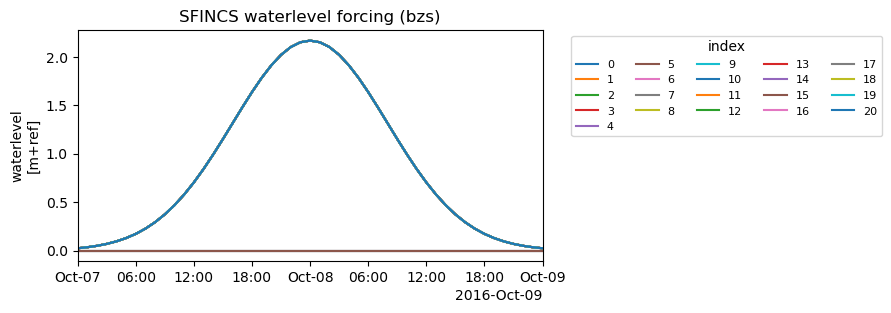

In [ ]:
import pandas as pd
import numpy as np
import openpyxl
import geopandas as gpd
import matplotlib.pyplot as plt

# USE MANUAL DATASET HERE TO FORCE DATA 
df_deltas = data_catalog.get_dataframe('combined_dataset_deltas')
storm_surge_delta = df_deltas.loc[df_deltas['BasinID2'] == target_basin_id, 'Storm_surge_height']

surge_height = storm_surge_delta.values[0]
print(f"Storm surge height for basin {target_basin_id}: {surge_height} m")

# 3. Create a synthetic surge time series (Gaussian curve)
tstart = pd.to_datetime(model_time_config['tstart'], format="%Y%m%d %H%M%S")
tstop = pd.to_datetime(model_time_config['tstop'], format="%Y%m%d %H%M%S")

# Create an hourly time index
time_index = pd.date_range(start=tstart, end=tstop, freq='1H')

# Calculate time in hours relative to start
t_hours = (time_index - tstart).total_seconds() / 3600
duration_hours = (tstop - tstart).total_seconds() / 3600

# Define Gaussian parameters
t_peak = duration_hours / 2  # Peak at the middle of the simulation
sigma = duration_hours / 6   # Width of the surge event

# Generate Gaussian surge profile
# Formula: H(t) = Hmax * exp(-0.5 * ((t - t_peak) / sigma)^2)
surge_values = surge_height * np.exp(-0.5 * ((t_hours - t_peak) / sigma)**2)

sf.setup_waterlevel_bnd_from_mask(distance=10000, 
                                  merge=False) # distances apart along coast 
gdf_bnd = sf.forcing["bzs"].vector.to_gdf()

# Create a DataFrame with the surge profile
# We use an integer column name (1) to match the location ID we will create
forcing_ts = pd.DataFrame(index=time_index)
for idx in gdf_bnd.index:
    forcing_ts[idx] = surge_values



# We increase the buffer to ensure the centroid (which might be far from the boundary) is included.
sf.setup_waterlevel_forcing(timeseries=forcing_ts, 
                            locations=gdf_bnd, 
                            buffer=False)

# Plot to visualise 
# The keys to access the model forcing
print(sf.forcing.keys())

# Plot the forcing
_ = sf.plot_forcing()

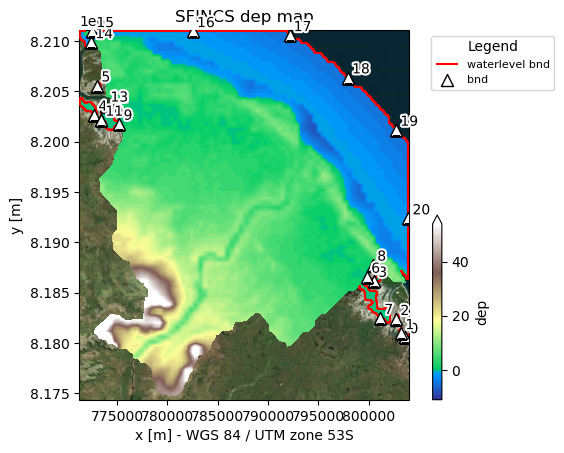

In [24]:
# Plot model summary so far, showing the GTSM points used for the waterlevel forcing
_ = sf.plot_basemap(variable='dep', bmap='sat')

## **Step 5:** Observation points and lines

The final output of the model will generally not be stored with the same temporal resolution the model uses during calculations to keep the output size in check. We can however specify some points and lines, called observation points and lines for which the model outputs are tracked with the higher temporal resolution. Observation points track the water level, while observation lines track the flow volumes passing through that line.

The geometry of the observation points and lines are  provided as geojson files. In our exercise we will only add observation points.
Create your own geojson by going to http://geojson.io and create observation points in SFINCS. 
To do so we use the `setup_observation_points` function, calling the geojson that you made.

For more information about this function see: 
https://deltares.github.io/hydromt_sfincs/latest/_generated/hydromt_sfincs.SfincsModel.setup_observation_points.html

In [ ]:
# # Path to observation points & lines geometries
# # obs_points_fn = Path(r'geojsons\YOUR_OBS_POINTS_GEOJSON')

# # Setup observation. merge argument handles whether to override or not
# sf.setup_observation_points(locations=obs_points_fn, merge=False)

# # Print the keys to access the observation geometries
# sf.geoms.keys()

2025-12-19 13:03:51,371 - SFINCS_log_charleston - geodataframe - INFO - Reading  vector data from geojsons\obs_points_charleston.geojson
2025-12-19 13:03:51,384 - SFINCS_log_charleston - geodataframe - DEBUG - Clip intersects [554679.000, 3593177.000, 627479.000, 3678977.000] (EPSG:32617)
2025-12-19 13:03:51,389 - SFINCS_log_charleston - model_api - WARNING - Replacing geom: obs


dict_keys(['region', 'obs'])

Finally we plot a summary of our model. This shows the boundary used as waterlevel, the points in the GTSM data used for the waterlevel forcing, and the observation points and lines.

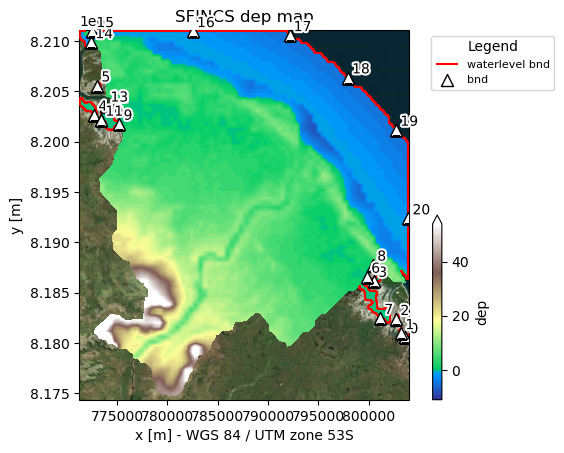

In [25]:
_ = sf.plot_basemap(variable='dep',bmap='sat')

## **Step 6:** Save model

Before running the model you need to save it. You can also update and finetune it later by reading it back in append mode. Fill in the cell below to save your model:

In [26]:
#SAVE YOUR MODEL:
sf.write()

2025-12-23 08:49:33,754 - SFINCS_log - sfincs - INFO - Writing model data to c:\PhD\SFINCS\SFINCS_Kiara\hands_on\code\outputs\sfincs_620947
2025-12-23 08:49:33,755 - SFINCS_log - sfincs - DEBUG - Write binary map indices based on mask.
2025-12-23 08:49:33,760 - SFINCS_log - sfincs - DEBUG - Write binary map files: ['msk', 'dep', 'scs', 'manning'].
2025-12-23 08:50:04,683 - SFINCS_log - sfincs - INFO - Write raster file(s) for grid to 'gis' subfolder
2025-12-23 08:50:38,769 - SFINCS_log - sfincs - INFO - Write geom files
2025-12-23 08:50:38,800 - SFINCS_log - sfincs - INFO - Write vector file(s) for geoms to 'gis' subfolder
2025-12-23 08:50:39,043 - SFINCS_log - sfincs - INFO - Write forcing files
2025-12-23 08:50:39,174 - SFINCS_log - sfincs - INFO - Write vector file(s) for forcing.bzs to 'gis' subfolder
2025-12-23 08:50:39,199 - SFINCS_log - sfincs - WARNING - zsini not in states, skipping


In [27]:
print(sf.grid)

<xarray.Dataset> Size: 3MB
Dimensions:      (x: 326, y: 365)
Coordinates:
    spatial_ref  int32 4B 0
  * x            (x) float64 3kB 7.714e+05 7.715e+05 ... 8.038e+05 8.039e+05
  * y            (y) float64 3kB 8.175e+06 8.175e+06 ... 8.211e+06 8.211e+06
Data variables:
    dep          (y, x) float64 952kB 40.0 39.0 38.0 37.0 ... -11.0 -11.0 -11.0
    msk          (y, x) uint8 119kB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0
    manning      (y, x) float64 952kB 0.04 0.04 0.04 0.04 ... 0.02 0.02 0.02
    scs          (y, x) float64 952kB dask.array<chunksize=(365, 326), meta=np.ndarray>


Saving the model will create a standard folder structure to be used when reading a model in. This folder structure can be inspected with:

In [28]:
def print_directory_tree(directory):
    for root, dirs, files in os.walk(directory):
        level = root.replace(directory, '').count(os.sep)
        indent = ' ' * 2 * (level)
        print('{}{}/'.format(indent, os.path.basename(root)))
        subindent = ' ' * 2 * (level + 1)
        for f in files:
            print(f'{subindent}+ {f}')

print_directory_tree(sf.root)

sfincs_620947/
  + hydromt.log
  + sfincs.bnd
  + sfincs.bzs
  + sfincs.ind
  + sfincs.inp
  + sfincs.log
  + sfincs.msk
  + sfincs.scs
  + sfincs_log.txt
  + sfincs_map.nc
  + sfincs_subgrid.nc
  figs/
    + zsmax.png
  gis/
    + bnd.geojson
    + dep.tif
    + manning.tif
    + msk.tif
    + region.geojson
    + scs.tif
  subgrid/
    + dep_subgrid.tif


## **Step 7:** Running your model
We have now set up our own SFINCS model for Charleston, well done! We are now ready to run the model. In order to do so, the only thing you need to do is call the sfincs executable (located in the *bin* folder). The easiest way to do so is copy the .bat file from one of the existing Charleston models towards your new model folder. After this you can double click the .bat file and the model will start running. The logging is written to the sfincs_log.txt file. 

In [29]:
# NOTE you need to download the SFINCS executable first (see first notebook) and update the path below
sfincs_exe = Path("../../software", "SFINCS_v2.3.0_mt_Faber_release_exe", "sfincs.exe")

run_sfincs(
    sf.root, # path to the SFINCS model root folder
    sfincs_exe=sfincs_exe, # path to the sfincs executable if you want to run SFINCS on windows
    vm=None, # you can use 'docker' if you want to run SFINCS on linux or mac, but you need to install docker desktop first
)

>> c:\PhD\SFINCS\SFINCS_Kiara\software\SFINCS_v2.3.0_mt_Faber_release_exe\sfincs.exe


------------ Welcome to SFINCS ------------

  @@@@@  @@@@@@@ @@ @@  @@   @@@@   @@@@@
 @@@ @@@ @@@@@@@ @@ @@@ @@ @@@@@@@ @@@ @@@
 @@@     @@      @@ @@@ @@ @@   @@ @@@
  @@@@@  @@@@@@  @@ @@@@@@ @@       @@@@@
     @@@ @@      @@ @@ @@@ @@   @@     @@@
 @@@ @@@ @@      @@ @@  @@  @@@@@@ @@@ @@@
  @@@@@  @@      @@ @@   @   @@@@   @@@@@

              ..............
          ......:@@@@@@@@:......
       ..::::..@@........@@.:::::..
     ..:::::..@@..::..::..@@.::::::..
    .::::::..@@............@@.:::::::.
   .::::::..@@..............@@.:::::::.
  .::::::::..@@............@@..::::::::.
 .:::::::::...@@.@..@@..@.@@..::::::::::.
 .:::::::::...:@@@..@@..@@@:..:::::::::..
 ............@@.@@..@@..@@.@@............
 ^^^~~^^~~^^@@..............@@^^^~^^^~~^^
 .::::::::::@@..............@@.:::::::::.
  .......:.@@.....@.....@....@@.:.......
   .::....@@......@.@@@.@....@@.....::.
    .:::~@@.:...:.@@...@@.

## **Step 8:** Inspecting the results: floodmap
Inspect the results of the model run by plotting the maximum water level on a map. In order to do so you should first read the results of the model (*sf.read_results()*). After this you can access the results by using the results attribute: *sf.results*.
The results you can plot using matplotlib.

*Tip: Print all available result keys by typing `print(sf.results.keys())`*  
*Tip:* You can also plot the results on top of the SFINCS basemap

In [30]:
# hmax is computed by SFINCS and read-in from the sfincs_map.nc file

sf.read_results()

sf.results.keys()

dict_keys(['inp', 'msk', 'zb', 'zs', 'zsmax', 'total_runtime', 'average_dt', 'status'])

Text(0.5, 1.0, 'SFINCS maximum water depth')

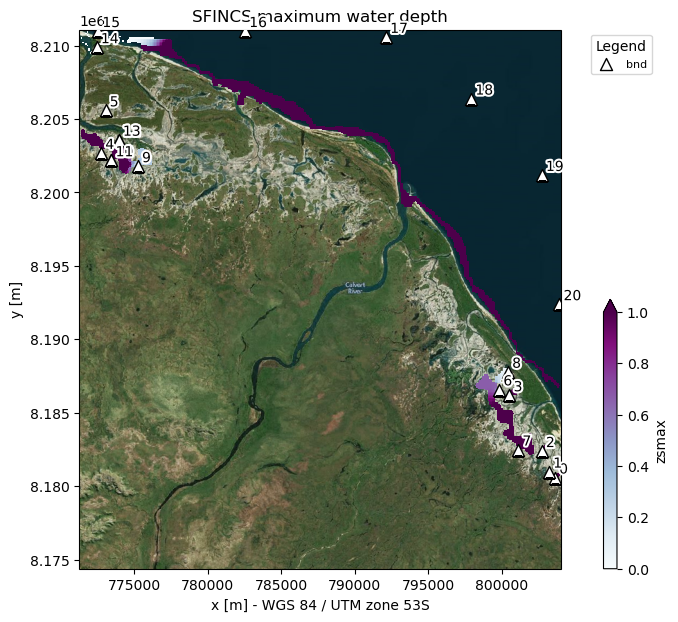

In [31]:
# variable to plot: maximum water depth
# plot_variable = <SET_PLOT_VARIABLE>
plot_variable = 'zsmax'
var = sf.results[plot_variable].max(dim='timemax').where(sf.grid['dep'] > -1)

fig, ax = sf.plot_basemap(
    fn_out="zsmax.png", # save figure to mod.root/figs/hmax.png
    variable= var, 
    plot_bounds=False,
    bmap="sat",
    zoomlevel=12,
    figsize=(11, 7),
    vmin=0, # set minimum value for colorbar
    vmax=1, # set maximum value for colorbar
    cmap="BuPu",
)

ax.set_title(f"SFINCS maximum water depth")


## **Step 9:** Inspecting the results: Timeseries
Inspect the results of the model run by plotting the waterlevels at the observation stations. The timeseries data you can access in a similar way using the results attribute of your model class. 

*Tip: Print all available result keys by typing `print(sf.results.keys())`*  

In [32]:
print(sf.results.keys())
sf.results['point_zs'].plot.line(x='time')

dict_keys(['inp', 'msk', 'zb', 'zs', 'zsmax', 'total_runtime', 'average_dt', 'status'])


KeyError: 'point_zs'